# Teoria de Grafos aplicada ao Zachary's Karate Club

Este notebook aplica conceitos de **Teoria de Grafos** ao dataset clássico **Zachary's Karate Club**, utilizando a biblioteca `networkx`.

Serão abordados:

- Análise exploratória dos dados  
- Criação/visualização do grafo  
- Medidas de centralidade:
  - Grau
  - Proximidade (Closeness)
  - Intermediação (Betweenness)
  - PageRank  
- Detecção de comunidades (extra)  
- Interpretação das medidas de centralidade no contexto da rede


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configuração opcional para exibição inline (caso esteja no Jupyter)
%matplotlib inline

## 1. Carregando o dataset

In [2]:
# Carrega o grafo clássico do clube de karatê de Zachary
G = nx.karate_club_graph()

print(G)

Graph named "Zachary's Karate Club" with 34 nodes and 78 edges


## 2. Análise Exploratória dos Dados

In [3]:
num_nos = G.number_of_nodes()
num_arestas = G.number_of_edges()

print(f"Número de nós: {num_nos}")
print(f"Número de arestas: {num_arestas}")

# Distribuição de graus
graus = dict(G.degree())
serie_graus = pd.Series(graus, name='grau').sort_values(ascending=False)
display(serie_graus.head(10))

grau_medio = serie_graus.mean()
print(f"Grau médio da rede: {grau_medio:.2f}")

Número de nós: 34
Número de arestas: 78


33    17
0     16
32    12
2     10
1      9
3      6
31     6
23     5
8      5
13     5
Name: grau, dtype: int64

Grau médio da rede: 4.59


## 3. Visualização do Grafo

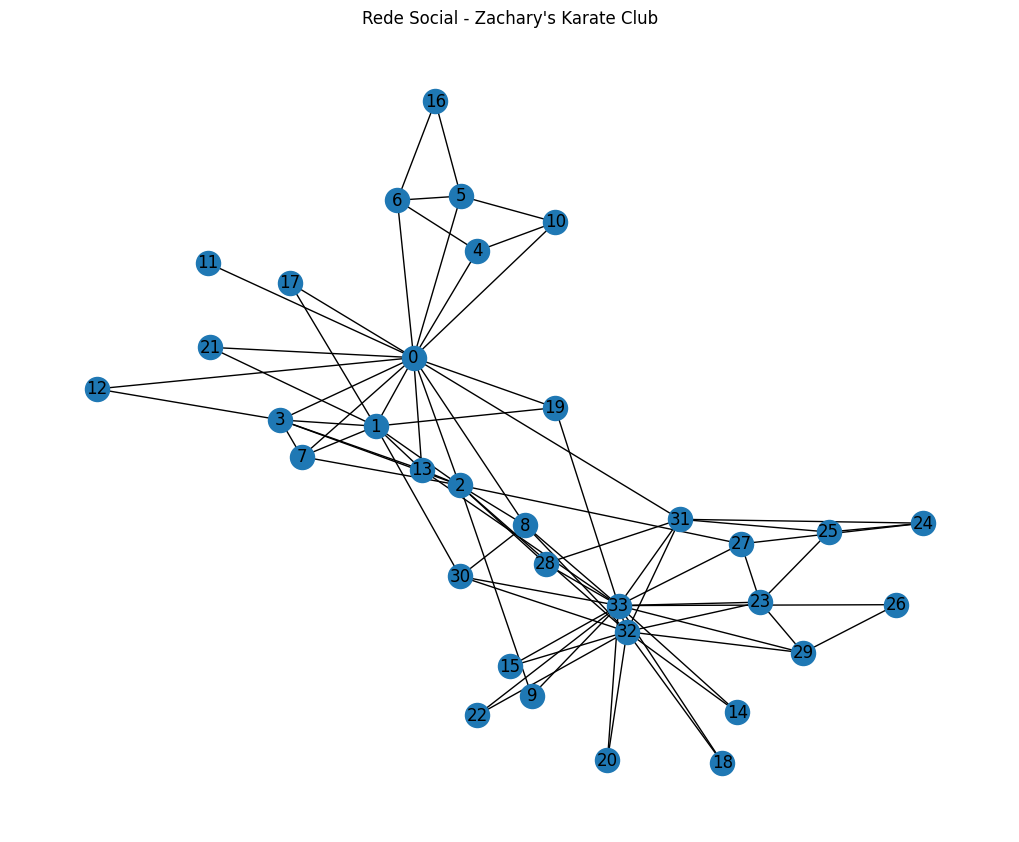

In [4]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)  # layout para visualização
nx.draw(G, pos, with_labels=True)
plt.title("Rede Social - Zachary's Karate Club")
plt.show()

## 4. Medidas de Centralidade

In [5]:
# Centralidade de Grau
centralidade_grau = nx.degree_centrality(G)

# Centralidade de Proximidade
centralidade_prox = nx.closeness_centrality(G)

# Centralidade de Intermediação
centralidade_inter = nx.betweenness_centrality(G, normalized=True)

# PageRank
pagerank = nx.pagerank(G)

# Monta DataFrame consolidado
df_centralidade = pd.DataFrame({
    'grau': pd.Series(centralidade_grau),
    'proximidade': pd.Series(centralidade_prox),
    'intermediacao': pd.Series(centralidade_inter),
    'pagerank': pd.Series(pagerank)
})

df_centralidade.index.name = 'no'
df_centralidade.sort_values('grau', ascending=False, inplace=True)

display(df_centralidade.head(10))

,grau,proximidade,intermediacao,pagerank
no,,,,
33,0.515152,0.550000,0.304075,0.096980
0,0.484848,0.568966,0.437635,0.088508
32,0.363636,0.515625,0.145247,0.075926
2,0.303030,0.559322,0.143657,0.062767
1,0.272727,0.485294,0.053937,0.057415
3,0.181818,0.464789,0.011909,0.037212
31,0.181818,0.540984,0.138276,0.041985
23,0.151515,0.392857,0.017614,0.041146
8,0.151515,0.515625,0.055927,0.033382


### 4.1 Visualização do grafo colorido por centralidade de grau

C:\Users\DESKTOP-MMAM\AppData\Local\Temp\ipykernel_19468\1791498451.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


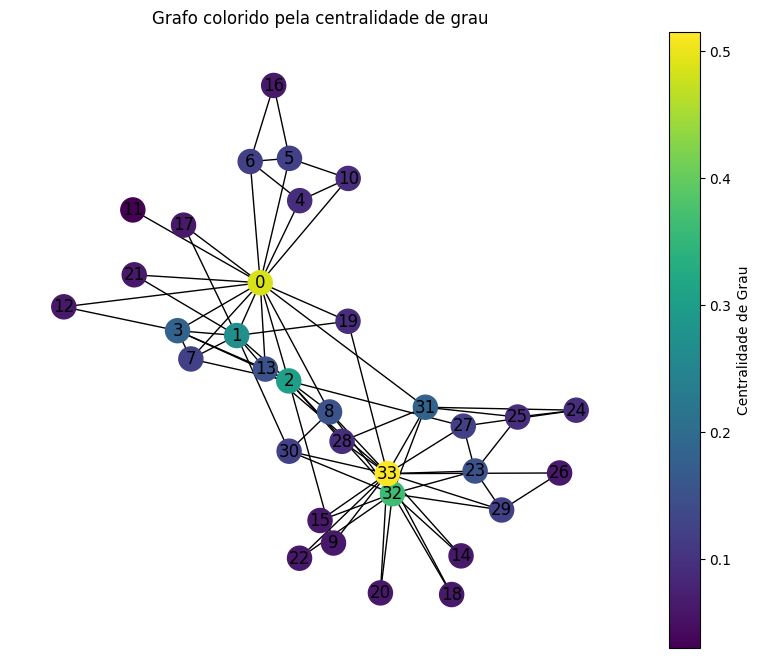

In [6]:
from matplotlib import cm, colors

fig, ax = plt.subplots(figsize=(10, 8))

valores_grau = [centralidade_grau[n] for n in G.nodes()]
cmap = cm.get_cmap('viridis')
norm = colors.Normalize(vmin=min(valores_grau), vmax=max(valores_grau))

nodes = nx.draw(
    G, pos, with_labels=True,
    node_size=300,
    node_color=valores_grau,
    cmap=cmap,
    ax=ax
)

ax.set_title("Grafo colorido pela centralidade de grau")

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Centralidade de Grau")

plt.show()


### 4.2 Visualização do grafo colorido por PageRank

C:\Users\DESKTOP-MMAM\AppData\Local\Temp\ipykernel_19468\2323308423.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


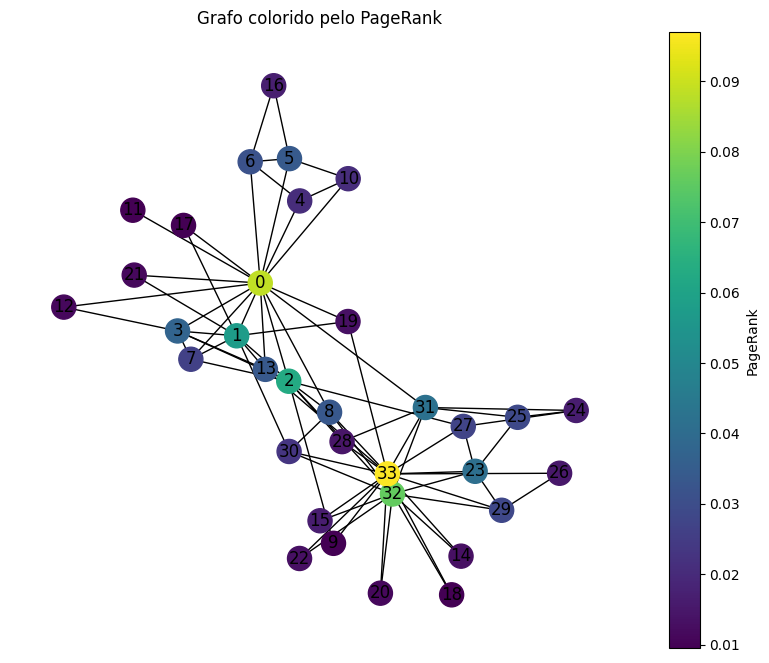

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

valores_grau = [pagerank[n] for n in G.nodes()]
cmap = cm.get_cmap('viridis')
norm = colors.Normalize(vmin=min(valores_grau), vmax=max(valores_grau))

nodes = nx.draw(
    G, pos, with_labels=True,
    node_size=300,
    node_color=valores_grau,
    cmap=cmap,
    ax=ax
)

ax.set_title("Grafo colorido pelo PageRank")

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="PageRank")

plt.show()


## 5. Interpretação das Medidas de Centralidade

- **Centralidade de Grau:** mostra quais nós possuem mais conexões diretas (popularidade).  
- **Centralidade de Proximidade:** indica quais nós estão, em média, mais próximos dos demais (espalham informação rapidamente).  
- **Centralidade de Intermediação (Betweenness):** identifica nós que atuam como "pontes" entre comunidades (controlam o fluxo de informação).  
- **PageRank:** mede a importância dos nós considerando não apenas a quantidade de conexões, mas a importância de quem está conectado a eles.

No grafo do Karate Club, nós com valores elevados nessas métricas tendem a representar:
- líderes locais na rede,
- pontos de mediação entre subgrupos,
- indivíduos com potencial maior de influência sobre decisões ou divisão da comunidade.

## 6. Extra: Detecção de Comunidades

In [ ]:
from networkx.algorithms import community

# Usa um método de detecção de comunidades baseado em modularidade
comunidades = community.greedy_modularity_communities(G)

print(f"Número de comunidades encontradas: {len(comunidades)}")
for i, c in enumerate(comunidades):
    print(f"Comunidade {i}: {sorted(list(c))}")

Número de comunidades encontradas: 3
Comunidade 0: [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Comunidade 1: [1, 2, 3, 7, 9, 12, 13, 17, 21]
Comunidade 2: [0, 4, 5, 6, 10, 11, 16, 19]


C:\Users\DESKTOP-MMAM\AppData\Local\Temp\ipykernel_41956\4238988134.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap('viridis'),
C:\Users\DESKTOP-MMAM\AppData\Local\Temp\ipykernel_41956\4238988134.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  sm = cm.ScalarMappable(norm=norm, cmap=cm.get_cmap('viridis'))


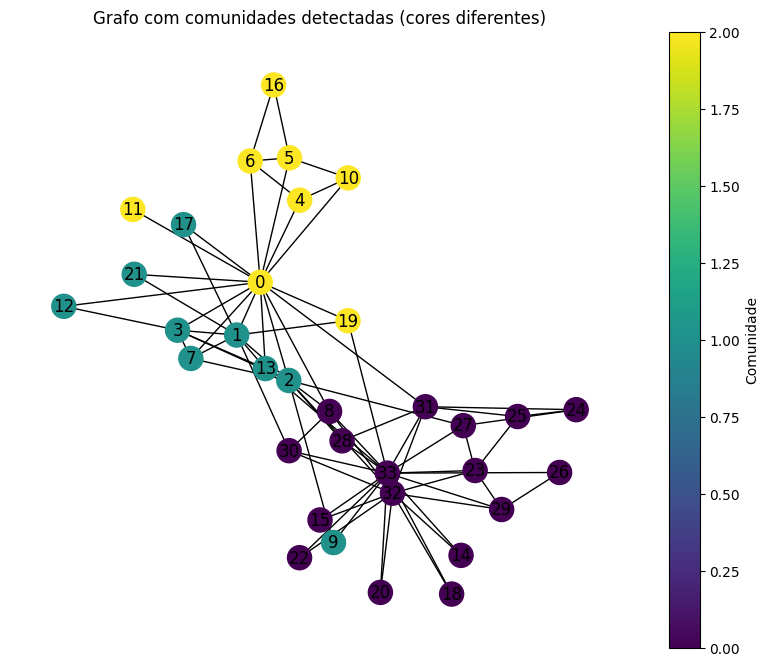

In [ ]:
from matplotlib import cm, colors

cores_comunidade = [comunidade_por_no[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(10, 8))

# Desenha o grafo no eixo ax
nodes = nx.draw(
    G, pos, with_labels=True,
    node_size=300,
    node_color=cores_comunidade,
    cmap=cm.get_cmap('viridis'),
    ax=ax
)

ax.set_title('Grafo com comunidades detectadas (cores diferentes)')

# Cria o mappable para a colorbar
norm = colors.Normalize(vmin=min(cores_comunidade), vmax=max(cores_comunidade))
sm = cm.ScalarMappable(norm=norm, cmap=cm.get_cmap('viridis'))
sm.set_array([])

fig.colorbar(sm, ax=ax, label='Comunidade')
plt.show()


### Interpretação das comunidades

As comunidades detectadas pelo algoritmo de modularidade representam grupos de nós que possuem mais conexões **entre si** do que com o restante da rede.  
Isso ajuda a entender **subgrupos coesos** dentro da rede social do clube de karatê, o que pode estar relacionado a afinidade, proximidade social ou até mesmo à divisão observada na história original do dataset.

## 7. Conclusão

Neste notebook, exploramos a Teoria de Grafos aplicada à rede social do Zachary's Karate Club, passando por:

- Análise exploratória básica (nós, arestas, graus)  
- Visualização do grafo  
- Cálculo de centralidades (grau, proximidade, intermediação, PageRank)  
- Detecção de comunidades (extra)  

A análise mostrou como medidas de centralidade podem ser usadas para identificar atores-chave na rede, bem como a estrutura de comunidades, permitindo interpretações sobre padrões de influência e relações sociais dentro de um grupo real.